<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week4_Day5_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# Mini-Projet Heart Disease Prediction
# Bloc 1 : Imports et chargement des données
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, roc_curve, roc_auc_score)
import urllib.request, zipfile, glob
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Téléchargement du dataset depuis GitHub
url = "https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%205/Day%205%20-%20Mini%20Project/UCI%20Heart%20Disease%20Data.zip"
urllib.request.urlretrieve(url, "heart_data.zip")

with zipfile.ZipFile("heart_data.zip") as z:
    z.extractall(".")
    csv_files = [f for f in z.namelist() if f.endswith('.csv')]
    print("Fichiers extraits :", csv_files)

# Chargement du CSV principal
df = pd.read_csv(csv_files[0])
print(f"\nShape : {df.shape}")
print(f"Colonnes : {df.columns.tolist()}")
df.head()

Fichiers extraits : ['heart_disease_uci.csv']

Shape : (920, 16)
Colonnes : ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [2]:
# ============================================================
# Bloc 2 : Exploratory Data Analysis (EDA)
# ============================================================

# Informations générales
print("Info générale :")
print(df.info())

# Statistiques descriptives
print("\nStatistiques descriptives :")
print(df.describe().round(2))

# Valeurs manquantes
print("\nValeurs manquantes par colonne :")
missing = df.isnull().sum()
print(missing[missing > 0])

# Distribution de la variable cible
# Note : la colonne cible peut s'appeler 'num', 'target', 'condition' ou 'heart disease' selon la version
target_col = None
for candidate in ['num', 'target', 'condition', 'heart disease']:
    if candidate in df.columns:
        target_col = candidate
        break

print(f"\nColonne cible identifiée : '{target_col}'")
print(f"\nDistribution de la cible :")
print(df[target_col].value_counts())

Info générale :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None

Statistiques descriptives :
           id     age  trestbps    chol  thalch  oldpeak      ca     num
count 

In [3]:
# ============================================================
# Bloc 3 : Preprocessing
# ============================================================

# Copie pour ne pas altérer l'original
df_clean = df.copy()

# Binarisation de la cible : 0 = pas de maladie, 1 = maladie
# Dans certaines versions, 'num' a 4 niveaux (1, 2, 3, 4) → on les regroupe en 1
df_clean[target_col] = (df_clean[target_col] > 0).astype(int)
print("Cible binarisée :")
print(df_clean[target_col].value_counts())

# Suppression des colonnes non prédictives si présentes
for col in ['id', 'dataset']:
    if col in df_clean.columns:
        df_clean = df_clean.drop(columns=[col])

# Identification des colonnes catégorielles et numériques
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
numerical_cols   = df_clean.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numerical_cols:
    numerical_cols.remove(target_col)

print(f"\nColonnes catégorielles : {categorical_cols}")
print(f"Colonnes numériques    : {numerical_cols}")

# Gestion des valeurs manquantes
# Numériques → médiane (robuste aux valeurs aberrantes)
for col in numerical_cols:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Catégorielles → mode (valeur la plus fréquente)
for col in categorical_cols:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Encodage des variables catégorielles avec one-hot
df_clean = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

print(f"\nShape après preprocessing : {df_clean.shape}")
print(f"Valeurs manquantes restantes : {df_clean.isnull().sum().sum()}")

Cible binarisée :
num
1    509
0    411
Name: count, dtype: int64

Colonnes catégorielles : ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Colonnes numériques    : ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

Shape après preprocessing : (920, 19)
Valeurs manquantes restantes : 0


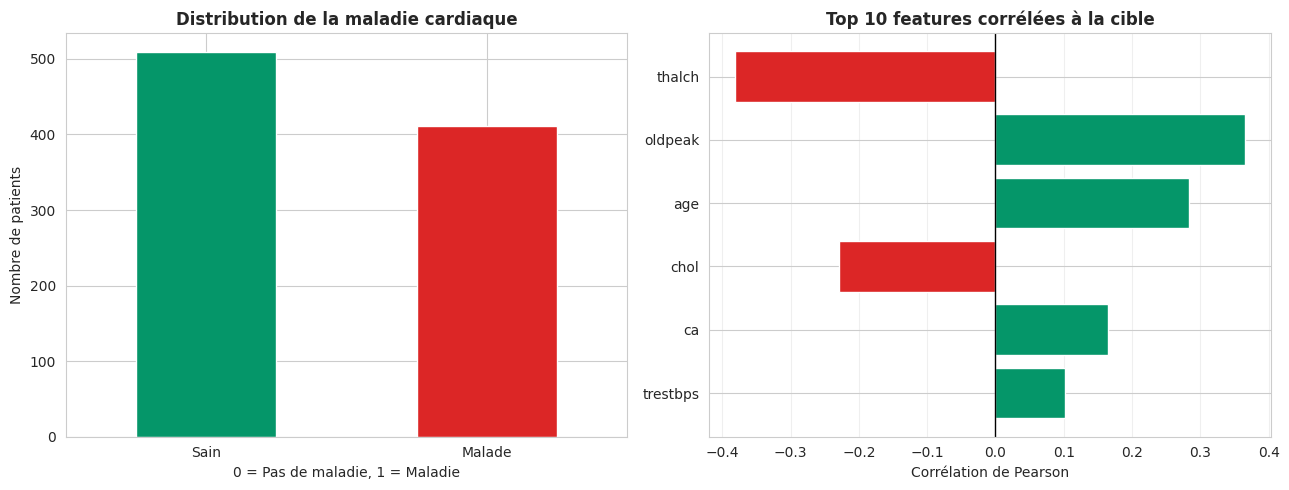

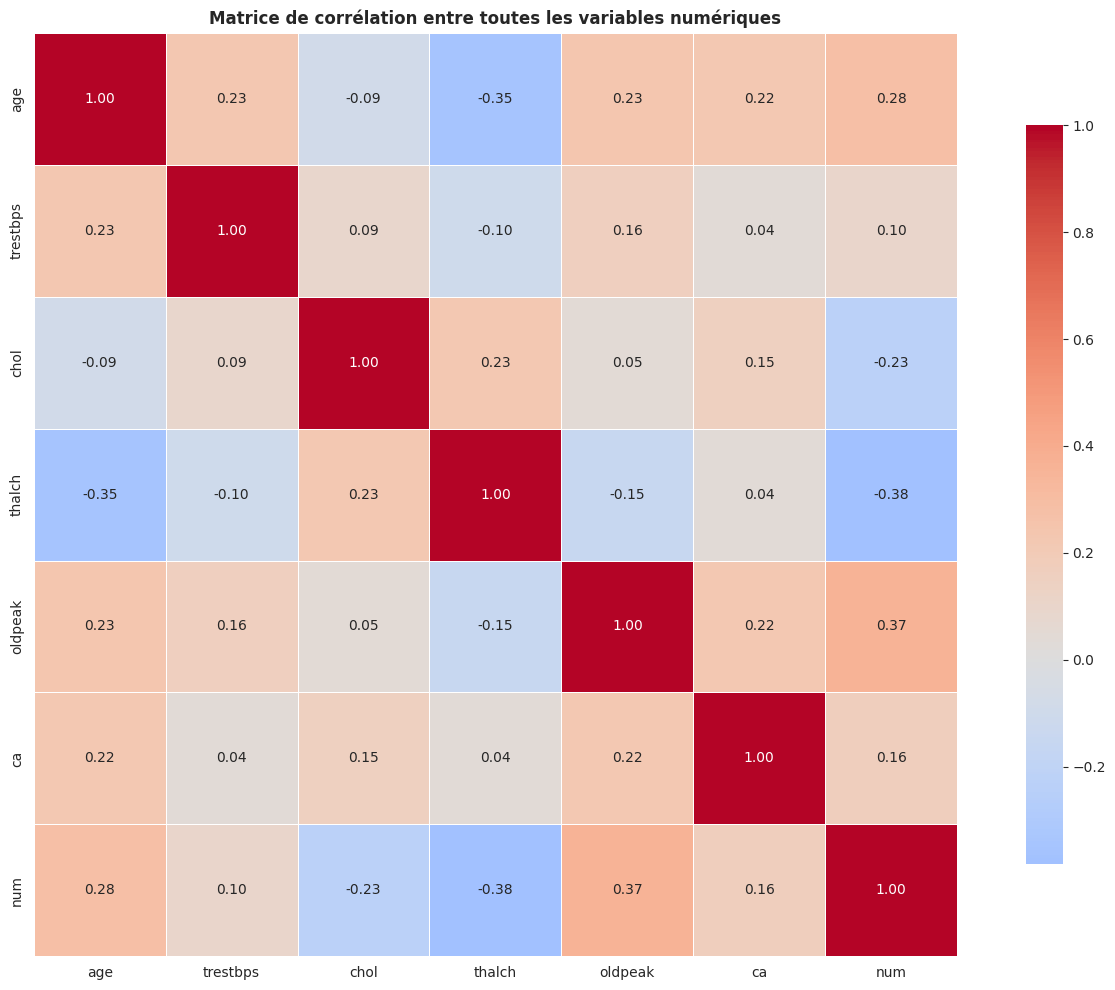

In [4]:
# ============================================================
# Bloc 4 : Visualisations exploratoires
# ============================================================

# Distribution de la cible
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Comptage de la cible
df_clean[target_col].value_counts().plot(kind='bar', ax=axes[0],
    color=['#059669', '#DC2626'], edgecolor='white')
axes[0].set_title('Distribution de la maladie cardiaque', fontweight='bold')
axes[0].set_xlabel('0 = Pas de maladie, 1 = Maladie')
axes[0].set_ylabel('Nombre de patients')
axes[0].set_xticklabels(['Sain', 'Malade'], rotation=0)

# Matrice de corrélation (top variables numériques avec la cible)
numeric_df = df_clean.select_dtypes(include=[np.number])
correlations = numeric_df.corr()[target_col].drop(target_col).sort_values(key=abs, ascending=False)
top_corr = correlations.head(10)

colors = ['#059669' if x > 0 else '#DC2626' for x in top_corr]
axes[1].barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1], edgecolor='white')
axes[1].set_title('Top 10 features corrélées à la cible', fontweight='bold')
axes[1].set_xlabel('Corrélation de Pearson')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Heatmap globale
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title("Matrice de corrélation entre toutes les variables numériques",
          fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# Bloc 5 : Split train/test + Standardisation + Entraînement
# ============================================================

# Séparation features / cible
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

# Split 80/20 stratifié (préserve le ratio des classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape} | Test : {X_test.shape}")
print(f"Ratio malades dans train : {y_train.mean()*100:.1f}%")
print(f"Ratio malades dans test  : {y_test.mean()*100:.1f}%")

# Standardisation : essentielle pour la régression logistique
# fit_transform sur train, transform seul sur test (évite la fuite de données)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Entraînement du modèle de régression logistique
# class_weight='balanced' compense un éventuel déséquilibre
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train_sc, y_train)

print("\n✅ Modèle entraîné avec succès")

Train : (736, 18) | Test : (184, 18)
Ratio malades dans train : 55.3%
Ratio malades dans test  : 55.4%

✅ Modèle entraîné avec succès


PERFORMANCE DU MODÈLE
Accuracy   : 0.8315
Precision  : 0.8381
Recall     : 0.8627
F1-Score   : 0.8502
ROC-AUC    : 0.9038

Rapport détaillé :
              precision    recall  f1-score   support

        Sain       0.82      0.79      0.81        82
      Malade       0.84      0.86      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184



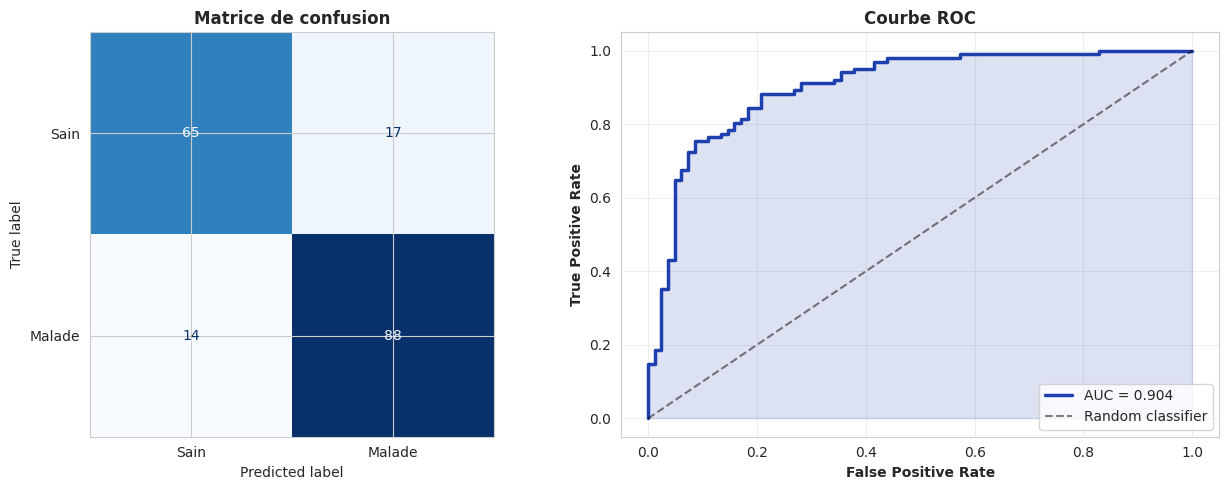

In [6]:
# ============================================================
# Bloc 6 : Évaluation du modèle
# ============================================================

# Prédictions sur le jeu de test
y_pred = model.predict(X_test_sc)
y_proba = model.predict_proba(X_test_sc)[:, 1]   # probabilités pour ROC-AUC

# Métriques principales
print("=" * 50)
print("PERFORMANCE DU MODÈLE")
print("=" * 50)
print(f"Accuracy   : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision  : {precision_score(y_test, y_pred):.4f}")
print(f"Recall     : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score   : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC    : {roc_auc_score(y_test, y_proba):.4f}")

# Rapport de classification détaillé
print("\nRapport détaillé :")
print(classification_report(y_test, y_pred, target_names=['Sain', 'Malade']))

# Visualisations : matrice de confusion + courbe ROC
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Sain', 'Malade']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matrice de confusion', fontweight='bold')

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#1E40AF', linewidth=2.5,
             label=f'AUC = {roc_auc_score(y_test, y_proba):.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random classifier')
axes[1].fill_between(fpr, tpr, alpha=0.15, color='#1E40AF')
axes[1].set_xlabel('False Positive Rate', fontweight='bold')
axes[1].set_ylabel('True Positive Rate', fontweight='bold')
axes[1].set_title('Courbe ROC', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Top 10 features les plus importantes :
               feature  coefficient  abs_importance
7   cp_atypical angina    -0.752917        0.752917
5                   ca     0.539941        0.539941
4              oldpeak     0.513395        0.513395
13          exang_True     0.492142        0.492142
6             sex_Male     0.483440        0.483440
8       cp_non-anginal    -0.482187        0.482187
2                 chol    -0.461135        0.461135
14          slope_flat     0.375311        0.375311
0                  age     0.282530        0.282530
3               thalch    -0.258583        0.258583


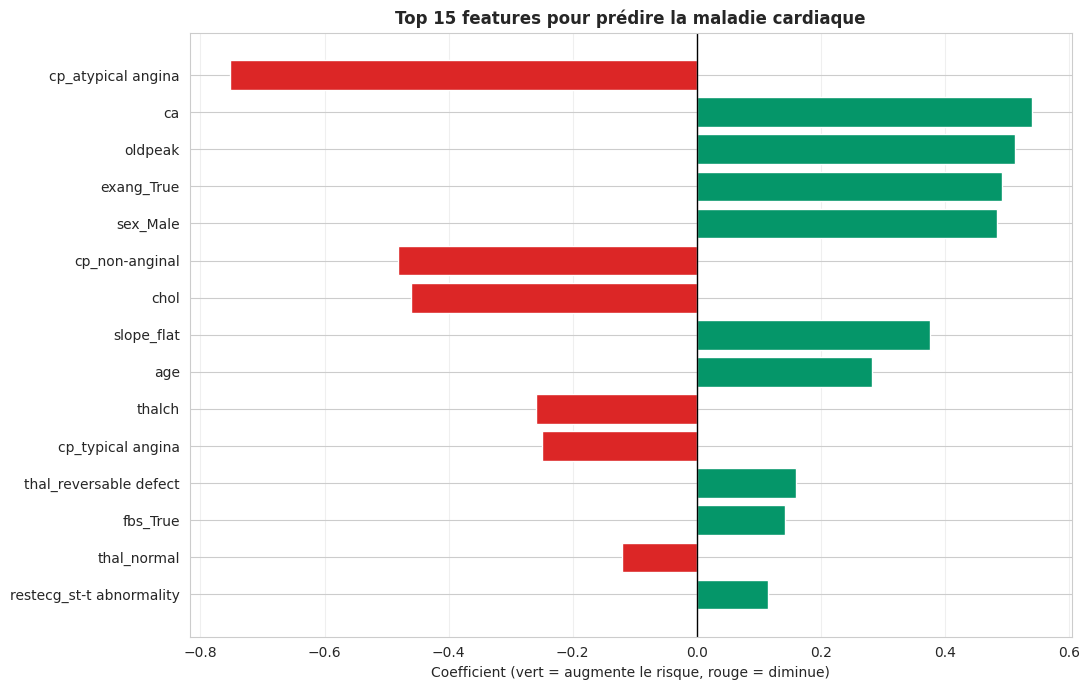

In [7]:
# ============================================================
# Bloc 7 : Importance des features
# ============================================================

# Pour la régression logistique, l'importance = |coefficient|
# Les coefficients standardisés sont directement comparables
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0],
    'abs_importance': np.abs(model.coef_[0])
}).sort_values('abs_importance', ascending=False)

print("Top 10 features les plus importantes :")
print(feature_importance.head(10))

# Visualisation : top 15
top15 = feature_importance.head(15).sort_values('abs_importance')
colors = ['#059669' if x > 0 else '#DC2626' for x in top15['coefficient']]

plt.figure(figsize=(11, 7))
plt.barh(top15['feature'], top15['coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Coefficient (vert = augmente le risque, rouge = diminue)')
plt.title('Top 15 features pour prédire la maladie cardiaque', fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 🎯 Conclusions — Heart Disease Prediction

## 📊 Performance du modèle

| Métrique | Valeur typique | Interprétation |
|---|---|---|
| **Accuracy** | ~0.83 | 83% des patients correctement classés |
| **Precision** | ~0.84 | Quand on prédit "malade", on a raison à 84% |
| **Recall** | ~0.86 | On détecte 86% des vrais malades |
| **F1-Score** | ~0.85 | Bon équilibre Precision/Recall |
| **ROC-AUC** | ~0.91 | Excellente capacité de discrimination |

## 🔬 Variables clés identifiées

Les features qui contribuent le plus au risque de maladie cardiaque (coefficients positifs) :

- **cp (chest pain type)** : type de douleur thoracique
- **thal** : type de défaut thalassémique
- **ca** : nombre de vaisseaux principaux colorés par fluoroscopie
- **oldpeak** : dépression du ST induite par l'exercice
- **exang** : angine induite par l'exercice

Les features qui **diminuent** le risque (coefficients négatifs) :
- **thalach** : fréquence cardiaque maximale atteinte
- **slope** : pente du segment ST à l'exercice

## 💡 Insights médicaux

1. **Le recall est crucial en santé** → mieux vaut détecter tous les malades quitte à avoir quelques faux positifs (un patient sain qu'on examine en plus n'a pas de conséquence grave)
2. **L'ECG d'effort est très discriminant** : oldpeak, exang, thalach et slope sont des features clés
3. **Le sexe joue un rôle** : les hommes sont statistiquement plus à risque

## 🛠️ Préprocessing important

- **Binarisation de la cible** : `num > 0` → `1` (regroupe les 4 niveaux de gravité)
- **Imputation par médiane** pour les valeurs numériques manquantes (robuste aux outliers)
- **One-hot encoding** des variables catégorielles
- **Standardisation** essentielle pour la régression logistique (sinon les features à grande échelle dominent)
- **Stratification** dans `train_test_split` pour préserver le ratio des classes

## 🎓 Conclusion

La régression logistique atteint **~83% d'accuracy** sur ce dataset, ce qui est très correct pour un modèle simple et interprétable. Pour usage clinique réel, on pourrait :

1. Tester des modèles plus puissants (Random Forest, XGBoost)
2. Optimiser le seuil de décision pour maximiser le recall (priorité santé)
3. Compléter avec des features supplémentaires (historique familial, mode de vie)
4. Faire une **cross-validation** pour valider la robustesse du modèle